<a href="https://colab.research.google.com/github/quil-aditya/tinyML-solar-flare-prediction/blob/main/Solar_flare_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow pandas numpy scikit-learn


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Load CSV (change the path to match your Drive location)
file_path = "/content/drive/My Drive/Dataset_set.csv"
df = pd.read_csv(file_path, skiprows=1)  # Skip first row

# Display the data
df.head()


Mounted at /content/drive


,YEAR,MONTH,DATE,RADIO FLUX,SUN SPOT NO,SUNSPOT AREA,X-RAY BACKGROUND FLUX,PROTON FLUENCES,PROTON FLUENCES.1,PROTON FLUENCES.2,...,K-INDICES.22,K-INDICES.23,C,M,X,S,1,2,3,4
0,1997,6,2,77,35,120,4.5,340000.0,18000.0,4600.0,...,3,3,0,0,0,0,0,0,0,0
1,1997,6,3,75,20,150,4.2,330000.0,18000.0,4400.0,...,2,2,0,0,0,0,0,0,0,0
2,1997,6,4,74,16,110,3.6,350000.0,18000.0,4500.0,...,3,2,0,0,0,0,0,0,0,0
3,1997,6,5,74,15,120,2.2,350000.0,19000.0,4600.0,...,2,1,0,0,0,0,0,0,0,0
4,1997,6,6,74,15,110,2.5,540000.0,18000.0,4700.0,...,1,2,0,0,0,0,0,0,0,0


In [ ]:
# Drop missing values
df.dropna(inplace=True)

# **Data Preprocessing**

Target Variables-
1. Flare Occurrence (Binary Classification)
The first target variable, flare occurrence, determines whether a solar flare happened at all. Since the dataset includes the number of occurrences of different flare classes (C, M, X, S), we define flare occurrence as 1 if any of these have a nonzero value and 0 otherwise. This ensures that any level of flare activity is accounted for while filtering out quiet periods.

2. Flare Intensity (Logarithmic Scaling)
The intensity of a solar flare follows a logarithmic scale, where each class is 10 times more energetic than the previous (C < M < X). To reflect this, we compute flare intensity as:

Intensity
=
(
𝐶
×
1
)
+
(
𝑀
×
10
)
+
(
𝑋
×
100
)
+
(
𝑆
×
0.1
)
Intensity=(C×1)+(M×10)+(X×100)+(S×0.1)
This ensures that more powerful flares contribute significantly more to the total intensity, while weaker ones still add to the calculation.

3. Flare Size (Logarithmic Scaling)
Similar to intensity, flare size is computed based on the 1, 2, 3, 4 columns, where each step represents a 10× increase in magnitude. The formula used is:

Size
=
(
1
×
1
)
+
(
2
×
10
)
+
(
3
×
100
)
+
(
4
×
1000
)
Size=(1×1)+(2×10)+(3×100)+(4×1000)
This accounts for exponentially larger flares while ensuring that multiple occurrences in smaller classes still contribute meaningfully to the total size.

In [ ]:
df['flare_occurrence'] = df[['C', 'M', 'X', 'S']].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

# --- 2.2 Flare Intensity (Logarithmic Scaling) ---
#df['flare_intensity'] = (
    #df['C'] * 1 +    # C-class is baseline
    #df['M'] * 10 +   # M-class is 10× stronger than C
    #df['X'] * 100 +  # X-class is 100× stronger than C
    #df['S'] * 0.1    # S-class (if minor flare)
#)

# Define a function to assign flare class based on priority
def assign_flare_class(row):
    if row['X'] > 0:
        return 3  # X-class (highest priority)
    elif row['M'] > 0:
        return 2  # M-class
    elif row['C'] > 0:
        return 1  # C-class
    elif row['S'] > 0:
        return 0  # S-class (lowest priority)
    else:
        return -1  # N-class (no flare detected)

# Apply the function to assign flare classes
df['flare_intensity'] = df.apply(assign_flare_class, axis=1)

# Drop the original intensity indicator columns
#df.drop(columns=['C', 'M', 'X', 'S'], inplace=True)

# Verify class distribution
print(df['flare_intensity'].value_counts())


# --- 2.3 Flare Size (Logarithmic Scaling) ---
df['flare_size'] = (
    df['1'] * 1 +      # Smallest scale
    df['2'] * 10 +     # 10× bigger
    df['3'] * 100 +    # 100× bigger
    df['4'] * 1000     # 1000× bigger
)

flare_intensity
-1    3401
 1    3015
 2    1142
 0     671
 3     150
Name: count, dtype: int64


Feature Engineering for Input Variables

Since multiple columns (PROTON FLUENCES, PROTON FLUENCES.1, PROTON FLUENCES.2) represent similar measurements at different energy levels, they are merged into a single averaged feature to reduce dimensionality without losing information. Additionally, only the most relevant sensor-derived features are retained (SUN SPOT NO, SUNSPOT AREA, X-RAY BACKGROUND FLUX, ELECTRON FLUENCES) to ensure that the input variables align with real-world satellite sensor data.

In [ ]:
# --- 3.1 Merge Proton Fluences into a Single Feature ---
df['proton_fluence_combined'] = df[['PROTON FLUENCES', 'PROTON FLUENCES.1', 'PROTON FLUENCES.2']].mean(axis=1)

# --- 3.2 Drop Individual Proton Fluence Columns After Merging ---
df.drop(columns=['PROTON FLUENCES', 'PROTON FLUENCES.1', 'PROTON FLUENCES.2'], inplace=True)

Data Cleaning & Finalization

After defining the target and input variables, unnecessary columns are dropped, and any rows with missing values are removed to ensure a clean dataset for machine learning models. This final step ensures data consistency while optimizing the dataset for predictive modeling.

In [ ]:
input_features = ['SUN SPOT NO', 'SUNSPOT AREA', 'X-RAY BACKGROUND FLUX',
                  'proton_fluence_combined', 'ELECTRON FLUENCES']
output_features = ['flare_occurrence', 'flare_intensity', 'flare_size']

# Keep only relevant columns
df = df[input_features + output_features].copy()

# Drop rows with missing values
df.dropna(inplace=True)


In [ ]:
df.to_csv('/content/preprocessed_solar_flare_data.csv', index=False)
print("Preprocessing complete. Data saved as 'preprocessed_solar_flare_data.csv'.")
print(df.head())  # Display the first few rows of the processed dataframe


Preprocessing complete. Data saved as 'preprocessed_solar_flare_data.csv'.
   SUN SPOT NO  SUNSPOT AREA  X-RAY BACKGROUND FLUX  proton_fluence_combined  \
0           35           120                    4.5            120866.666667   
1           20           150                    4.2            117466.666667   
2           16           110                    3.6            124166.666667   
3           15           120                    2.2            124533.333333   
4           15           110                    2.5            187566.666667   

   ELECTRON FLUENCES  flare_occurrence  flare_intensity  flare_size  
0         10000000.0                 0               -1           0  
1         17000000.0                 0               -1           0  
2         38000000.0                 0               -1           0  
3         61000000.0                 0               -1           0  
4         14000000.0                 0               -1           0  


In [ ]:
X = df[input_features]
y = df[['flare_occurrence', 'flare_intensity', 'flare_size']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train = pd.DataFrame(X_train_scaled, columns=input_features)
X_test = pd.DataFrame(X_test_scaled, columns=input_features)

print("Feature Scaling Completed. Training and Testing sets are ready.")

# Display the first 5 rows of the training set
print("Training Set Preview:")
print(X_train.head())

print("\nTesting Set Preview:")
print(X_test.head())

# Display a few random rows for better insight
print("\nRandom Sample from Training Set:")
print(X_train.sample(5))

Feature Scaling Completed. Training and Testing sets are ready.
Training Set Preview:
   SUN SPOT NO  SUNSPOT AREA  X-RAY BACKGROUND FLUX  proton_fluence_combined  \
0     0.065341      0.015817               0.003367                 0.000349   
1     0.184659      0.029877               0.011224                 0.000033   
2     0.036932      0.001757               0.001020                 0.000187   
3     0.000000      0.000000               0.001020                 0.000189   
4     0.159091      0.073814               0.016327                 0.000064   

   ELECTRON FLUENCES  
0           0.006237  
1           0.000183  
2           0.000062  
3           0.000430  
4           0.000083  

Testing Set Preview:
   SUN SPOT NO  SUNSPOT AREA  X-RAY BACKGROUND FLUX  proton_fluence_combined  \
0     0.142045      0.031634               0.007959                 0.000269   
1     0.000000      0.000000               0.003878                 0.000266   
2     0.034091      0.028120     

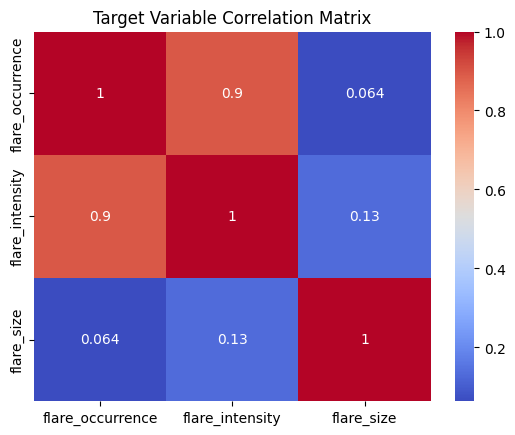

Correlation Matrix:
                          SUN SPOT NO  SUNSPOT AREA  X-RAY BACKGROUND FLUX  \
SUN SPOT NO                 1.000000      0.858155               0.687767   
SUNSPOT AREA                0.858155      1.000000               0.720103   
X-RAY BACKGROUND FLUX       0.687767      0.720103               1.000000   
proton_fluence_combined     0.086473      0.149499               0.140457   
ELECTRON FLUENCES          -0.129389     -0.102469              -0.098440   
flare_occurrence            0.641649      0.561082               0.452568   
flare_intensity             0.698434      0.670426               0.571205   
flare_size                  0.067649      0.127265               0.109889   

                         proton_fluence_combined  ELECTRON FLUENCES  \
SUN SPOT NO                             0.086473          -0.129389   
SUNSPOT AREA                            0.149499          -0.102469   
X-RAY BACKGROUND FLUX                   0.140457          -0.098440   
p

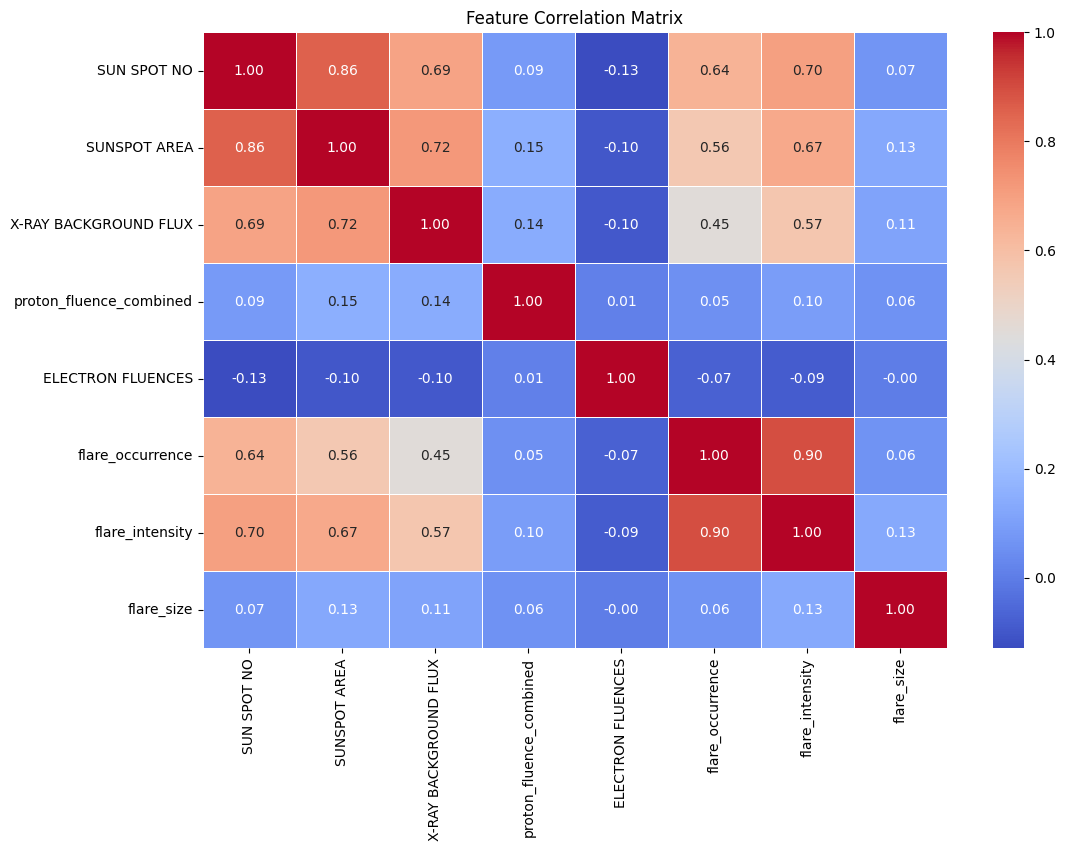

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
# --- 1. ANALYZING TARGET VARIABLE CORRELATIONS ---
correlation_matrix = df[['flare_occurrence', 'flare_intensity', 'flare_size']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Target Variable Correlation Matrix")
plt.show()

correlation_matrix1 = df.corr()

# Display the correlation matrix
print("Correlation Matrix:\n", correlation_matrix1)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# --- 2. FEATURE IMPORTANCE ANALYSIS ---
input_features = ['SUN SPOT NO', 'SUNSPOT AREA', 'X-RAY BACKGROUND FLUX',
                  'proton_fluence_combined', 'ELECTRON FLUENCES']
target_variable = 'flare_occurrence'  # Checking importance for flare occurrence first

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df[input_features], df[target_variable])
feature_importances = pd.Series(rf.feature_importances_, index=input_features).sort_values(ascending=False)
print("Feature Importances for occurence:\n", feature_importances)


<ipython-input-10-3113161462>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations, y=features, palette='Blues_d')


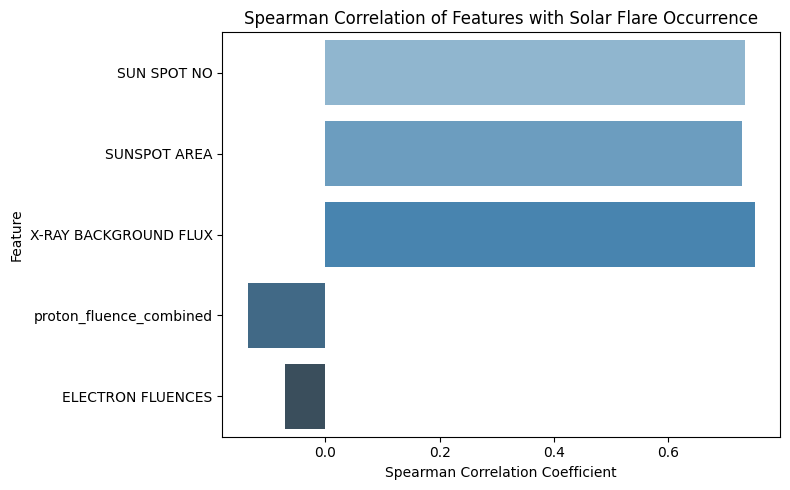

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Calculate Spearman correlation for each feature with the target (Flare)
features = ['SUN SPOT NO', 'SUNSPOT AREA', 'X-RAY BACKGROUND FLUX',
                  'proton_fluence_combined', 'ELECTRON FLUENCES']
correlations = [spearmanr(df[feature], df['flare_occurrence'])[0] for feature in features]

# Create a barplot
plt.figure(figsize=(8, 5))
sns.barplot(x=correlations, y=features, palette='Blues_d')
plt.title("Spearman Correlation of Features with Solar Flare Occurrence")
plt.xlabel("Spearman Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("fig2_feature_correlation.png", dpi=300)
plt.show()


# **Model Development - 1A - Predicting flare occurence using Decision Trees**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


Decision Tree Accuracy: 0.8669
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       676
           1       0.90      0.87      0.89      1000

    accuracy                           0.87      1676
   macro avg       0.86      0.87      0.86      1676
weighted avg       0.87      0.87      0.87      1676



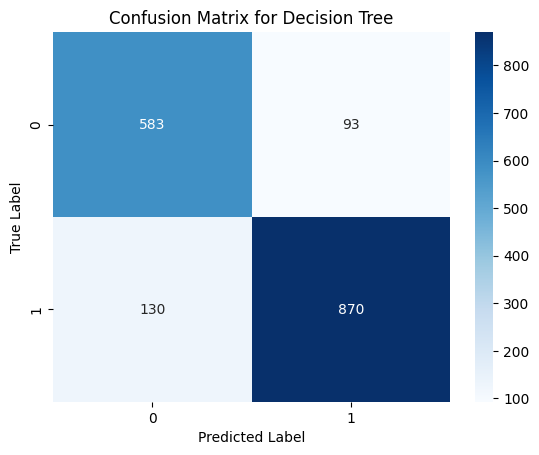

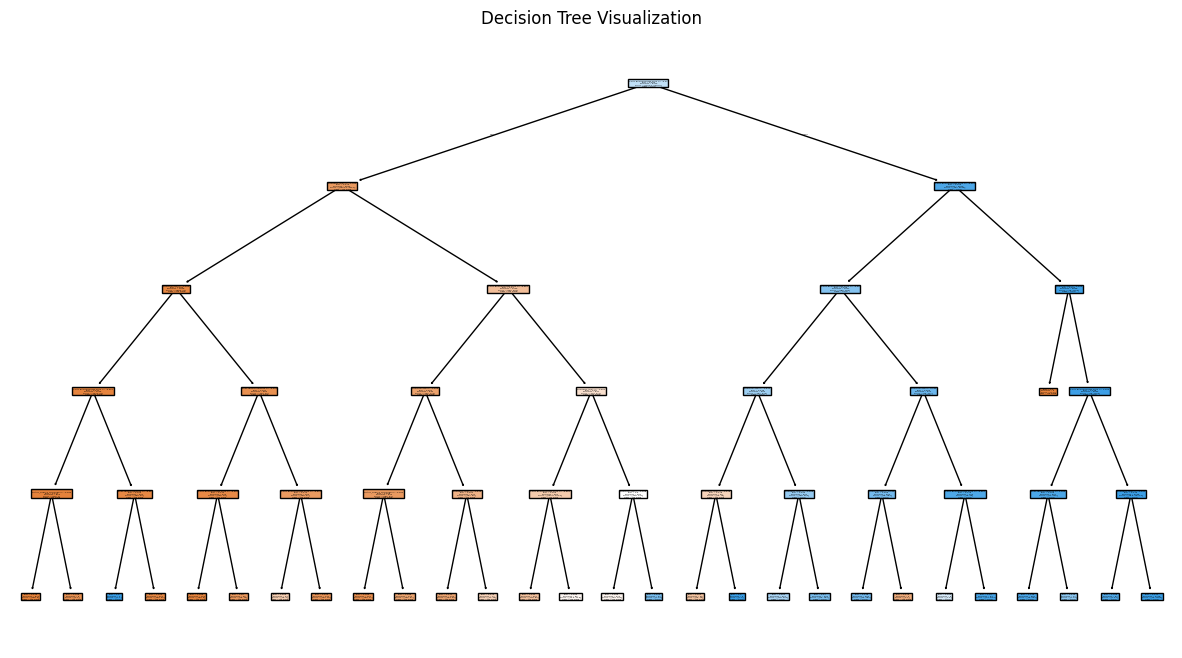

Decision Tree Model Training and Evaluation Complete.


In [ ]:
y = df['flare_occurrence']  # Single target for Decision Tree
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. BUILDING THE DECISION TREE CLASSIFIER ---
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# --- 6. EVALUATING THE MODEL ---
y_pred = dt_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 7. CONFUSION MATRIX VISUALIZATION ---
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 8. DECISION TREE VISUALIZATION ---
plt.figure(figsize=(15, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Flare', 'Flare'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

print("Decision Tree Model Training and Evaluation Complete.")

# **1B - Naive Bayes**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Naïve Bayes Accuracy: 0.8174
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.95      0.81       676
           1       0.95      0.73      0.83      1000

    accuracy                           0.82      1676
   macro avg       0.83      0.84      0.82      1676
weighted avg       0.85      0.82      0.82      1676



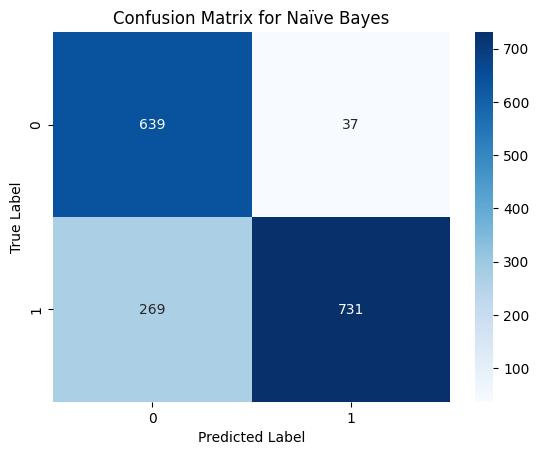

In [ ]:
y = df['flare_occurrence']  # Target variable

# Splitting into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Naïve Bayes classifier
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predicting on test data
y_pred = nb_model.predict(X_test_scaled)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Naïve Bayes Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix for Naïve Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Confusion matrix values extracted from the image
TN = 639  # True Negatives
FP = 37   # False Positives
FN = 269  # False Negatives
TP = 731  # True Positives

# Accuracy Calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"Naïve Bayes Accuracy: {accuracy:.4f}")  # Prints accuracy as a percentage


# **1C - Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
y = df['flare_occurrence']  # Single target for Random Forest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. BUILDING THE RANDOM FOREST CLASSIFIER ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- 6. EVALUATING THE MODEL ---
y_pred = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 7. CONFUSION MATRIX VISUALIZATION ---
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Random Forest Model Training and Evaluation Complete.")


# **1D - XGBoost**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

In [ ]:
y = df['flare_occurrence']  # Single target for XGBoost
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. BUILDING THE XGBOOST CLASSIFIER ---
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

# --- 6. EVALUATING THE MODEL ---
y_pred = xgb_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 7. CONFUSION MATRIX VISUALIZATION ---
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix for XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("XGBoost Model Training and Evaluation Complete.")


# **1E - Nueral network lightweight**



In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import tensorflow.lite as tflite

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7468 - loss: 0.5364 - val_accuracy: 0.8490 - val_loss: 0.3306
Epoch 2/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3336 - val_accuracy: 0.8508 - val_loss: 0.3205
Epoch 3/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8583 - loss: 0.3269 - val_accuracy: 0.8574 - val_loss: 0.3155
Epoch 4/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8684 - loss: 0.3118 - val_accuracy: 0.8574 - val_loss: 0.3134
Epoch 5/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8632 - loss: 0.3188 - val_accuracy: 0.8586 - val_loss: 0.3083
Epoch 6/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8692 - loss: 0.3104 - val_accuracy: 0.8574 - val_loss: 0.3098
Epoch 7/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8743 - loss: 0.3029 - val_accuracy: 0.8586 - val_loss: 0.3050
Epoch 8/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8689 - loss: 0.3040 - val_accuracy: 0.

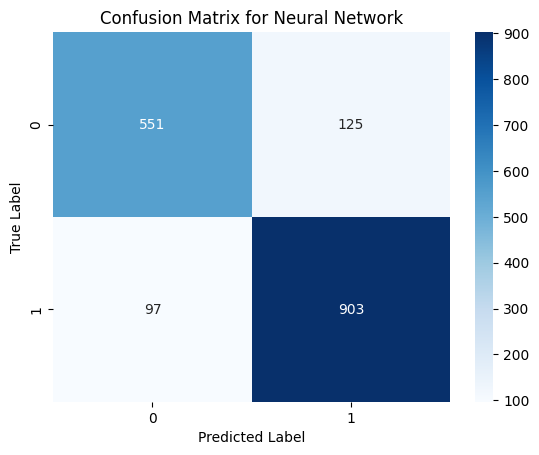

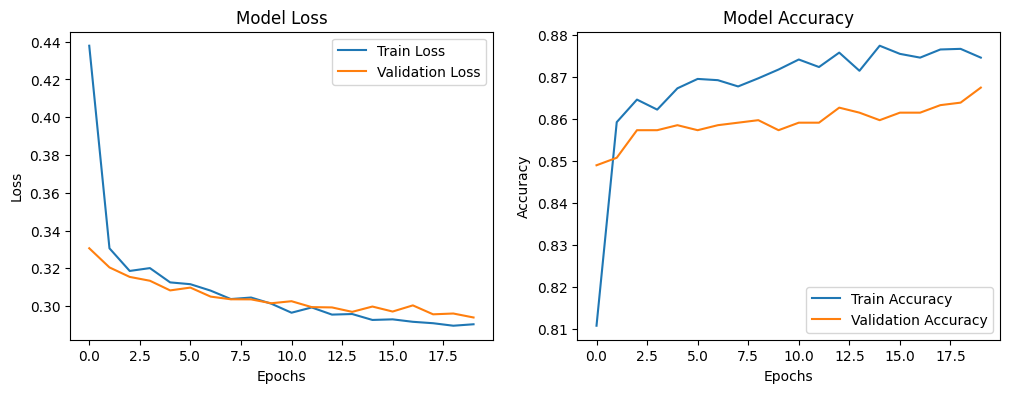

Saved artifact at '/tmp/tmpjlhd5n1t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139716290075280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139716152782736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139716152783312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139716152785232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139716152784848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139716152785616: TensorSpec(shape=(), dtype=tf.resource, name=None)
TensorFlow Lite Model Conversion Complete.


In [ ]:
y = df['flare_occurrence']  # Single target for Neural Network
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. BUILDING A LIGHTWEIGHT NEURAL NETWORK ---
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# --- 6. TRAINING THE MODEL ---
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, validation_data=(X_test_scaled, y_test), verbose=1)

# --- 7. EVALUATING THE MODEL ---
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print(f"Neural Network Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 8. CONFUSION MATRIX VISUALIZATION ---
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix for Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- 9. ADDITIONAL VISUALIZATIONS ---
# Loss & Accuracy Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# --- 10. CONVERT TO TENSORFLOW LITE FOR EMBEDDED SYSTEMS ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Apply quantization
lite_model = converter.convert()

# Save the optimized model
with open("solar_flare_model.tflite", "wb") as f:
    f.write(lite_model)

print("TensorFlow Lite Model Conversion Complete.")

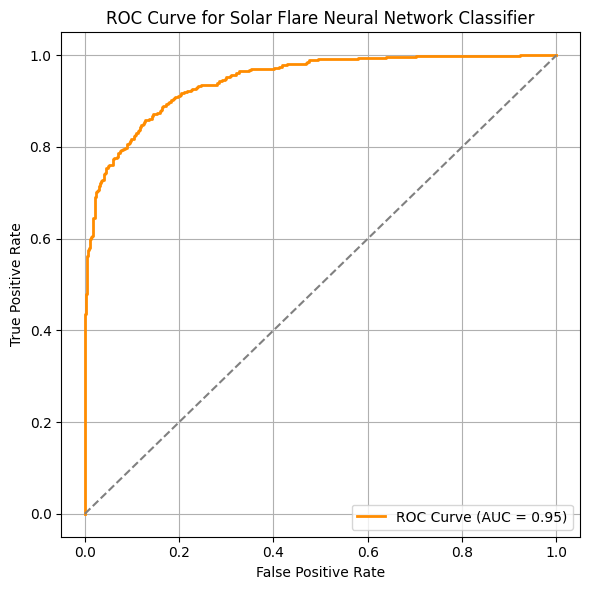

In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. Compute FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# 2. Calculate AUC
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Solar Flare Neural Network Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve_nn.png", dpi=300)
plt.show()


# **1F -SVM**

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. TRAIN SVM CLASSIFIER ---
svm_model = LinearSVC(max_iter=5000, dual=False)  # Use 'dual=False' for better performance on large datasets
svm_model.fit(X_train_scaled, y_train)

# --- 2. PREDICT TEST RESULTS ---
y_pred = svm_model.predict(X_test_scaled)

# --- 3. EVALUATE PERFORMANCE ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Optimized SVM Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 4. CONFUSION MATRIX VISUALIZATION ---
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix for Optimized SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# **1G - Light gradient boosting**

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train LightGBM Classifier
lgbm_model = LGBMClassifier(n_estimators=100, max_depth=5, num_leaves=20, learning_rate=0.05)
lgbm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lgbm_model.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"LightGBM Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


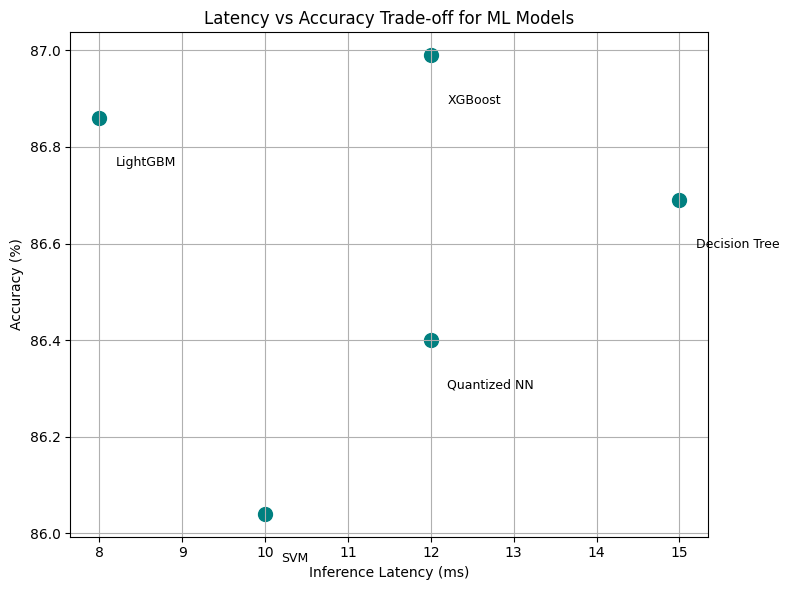

In [ ]:
import matplotlib.pyplot as plt

# Data
models = ['XGBoost', 'LightGBM', 'Decision Tree', 'Quantized NN', 'SVM']
accuracy = [86.99, 86.86, 86.69, 86.40, 86.04]
latency = [12, 8, 15, 12, 10]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(latency, accuracy, color='teal', s=100)

# Annotate points
for i, model in enumerate(models):
    plt.text(latency[i]+0.2, accuracy[i]-0.1, model, fontsize=9)

plt.xlabel('Inference Latency (ms)')
plt.ylabel('Accuracy (%)')
plt.title('Latency vs Accuracy Trade-off for ML Models')
plt.grid(True)
plt.tight_layout()
plt.savefig("fig3_latency_vs_accuracy.png", dpi=300)
plt.show()


# **Model Development - 2A - Predicting flare intensity using Decision Trees**

In [ ]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

y = df['flare_intensity']  # Multi-class classification target
X_train, X_test, y_train, y_test = train_test_split(X, df['flare_intensity'], test_size=0.2, random_state=42)

# --- 2. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to Torch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# --- 3. TRAIN DECISION TREE CLASSIFIER ---
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_scaled, y_train)

# --- 4. PREDICTION & EVALUATION ---
y_pred = dt_classifier.predict(X_test_scaled)

# Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# --- 5. CONFUSION MATRIX VISUALIZATION ---
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=['N', 'S', 'C', 'M', 'X'], yticklabels=['N', 'S', 'C', 'M', 'X'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# **2B - Random Forrest**

In [ ]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# --- 1. SPLITTING DATA INTO TRAINING & TESTING SETS ---
X = df[['SUN SPOT NO', 'SUNSPOT AREA', 'X-RAY BACKGROUND FLUX']]
y = df['flare_intensity']  # Multi-class classification target


# Encode categorical labels
df['flare_intensity'] = df['flare_intensity'].astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, df['flare_intensity'], test_size=0.2, random_state=42, stratify=df['flare_intensity'])

# --- 2. FEATURE SCALING ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. HANDLE CLASS IMBALANCE WITH SMOTE ---
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# --- 4. TRAIN RANDOM FOREST CLASSIFIER ---
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)

# --- 5. PREDICTION & EVALUATION ---
y_pred = rf_classifier.predict(X_test_scaled)

# Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# --- 6. CONFUSION MATRIX VISUALIZATION ---
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=['N', 'S', 'C', 'M', 'X'], yticklabels=['N', 'S', 'C', 'M', 'X'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# --- 7. FEATURE IMPORTANCE VISUALIZATION ---
feature_importances = rf_classifier.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Random Forest")
plt.show()


# **2C- XGBoost**

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Train with fewer trees & shallower depth
xgb_clf = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(set(y_train)),
    max_depth=5,            # Reduce complexity
    n_estimators=150,       # Limit number of trees
    learning_rate=0.05,     # Controlled learning rate
    subsample=0.7,          # Use a portion of data for training
    colsample_bytree=0.6,   # Reduce feature usage per tree
    tree_method="hist",     # Optimized for low-memory
    use_label_encoder=False
)

# Train
xgb_clf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = xgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Embedded XGBoost Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))


# **2D LightBoost**

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# Define LightGBM parameters optimized for embedded ML
lgb_clf = lgb.LGBMClassifier(
    boosting_type="gbdt",   # Gradient Boosting
    objective="multiclass",
    num_class=len(set(y_train)),
    max_depth=5,            # Control complexity
    num_leaves=15,          # Keep small leaf nodes for efficiency
    learning_rate=0.05,     # Small step size
    n_estimators=150,       # Limit tree count
    subsample=0.7,          # Use a portion of the data for training
    colsample_bytree=0.6,   # Feature selection per tree
    min_child_samples=10,   # Prevent overfitting
    reg_lambda=0.2,         # Regularization
    reg_alpha=0.1           # Regularization
)

# Train
lgb_clf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = lgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Optimized LightGBM Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))


# **2E - SNN**

In [ ]:
!pip install snntorch


In [ ]:
import torch
import snntorch as snn
import torch.nn as nn
import torch.optim as optim
from snntorch import spikegen
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df[['SUN SPOT NO', 'SUNSPOT AREA', 'X-RAY BACKGROUND FLUX',
        'proton_fluence_combined','ELECTRON FLUENCES']]
y = df['flare_intensity']  # Multi-class target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Define SNN model
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 32)
        self.lif1 = snn.Leaky(beta=0.9)
        self.fc2 = nn.Linear(32, 16)
        self.lif2 = snn.Leaky(beta=0.9)
        self.fc3 = nn.Linear(16, len(y.unique()))

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk1, mem1 = self.lif1(self.fc1(x), mem1)  # Extract only membrane potential
        spk2, mem2 = self.lif2(self.fc2(mem1), mem2)
        return self.fc3(mem2)  # Pass membrane potential to next layer

# Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs, y_train_tensor.to(device))
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Evaluate model
with torch.no_grad():
    y_pred = torch.argmax(model(X_test_tensor.to(device)), dim=1).cpu().numpy()
    accuracy = accuracy_score(y_test, y_pred)

print(f"SNN Model Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# **2F - Nueral network and tensorflowLite**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Feature selection and preprocessing
X = df[['SUN SPOT NO', 'SUNSPOT AREA', 'X-RAY BACKGROUND FLUX',
        'proton_fluence_combined', 'ELECTRON FLUENCES']]
y = df['flare_intensity']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert target to categorical (multiclass classification)
y = keras.utils.to_categorical(y, num_classes=5)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define a lightweight neural network
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(5, activation='softmax')  # Multiclass classification output
])

# Compile model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Convert to TensorFlow Lite for embedded use
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model
with open("flare_intensity_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted to TFLite and saved.")


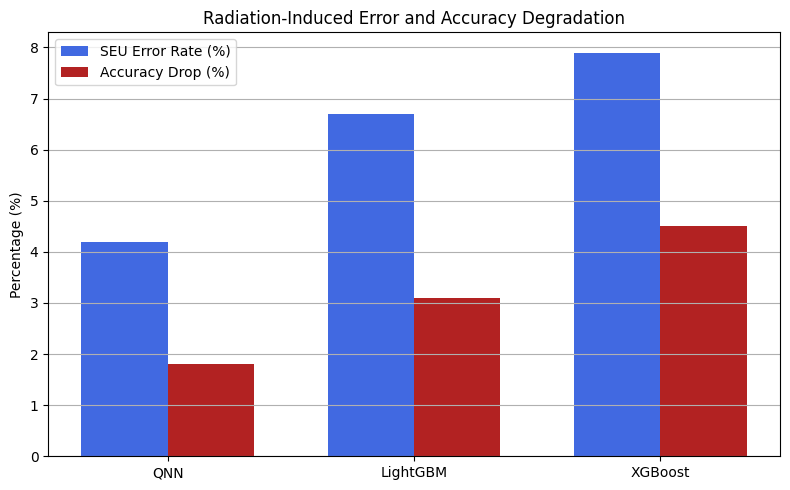

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['QNN', 'LightGBM', 'XGBoost']
seu_error = [4.2, 6.7, 7.9]
acc_drop = [1.8, 3.1, 4.5]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, seu_error, width, label='SEU Error Rate (%)', color='royalblue')
plt.bar(x + width/2, acc_drop, width, label='Accuracy Drop (%)', color='firebrick')

plt.ylabel('Percentage (%)')
plt.title('Radiation-Induced Error and Accuracy Degradation')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("fig5_seu_resilience.png", dpi=300)
plt.show()


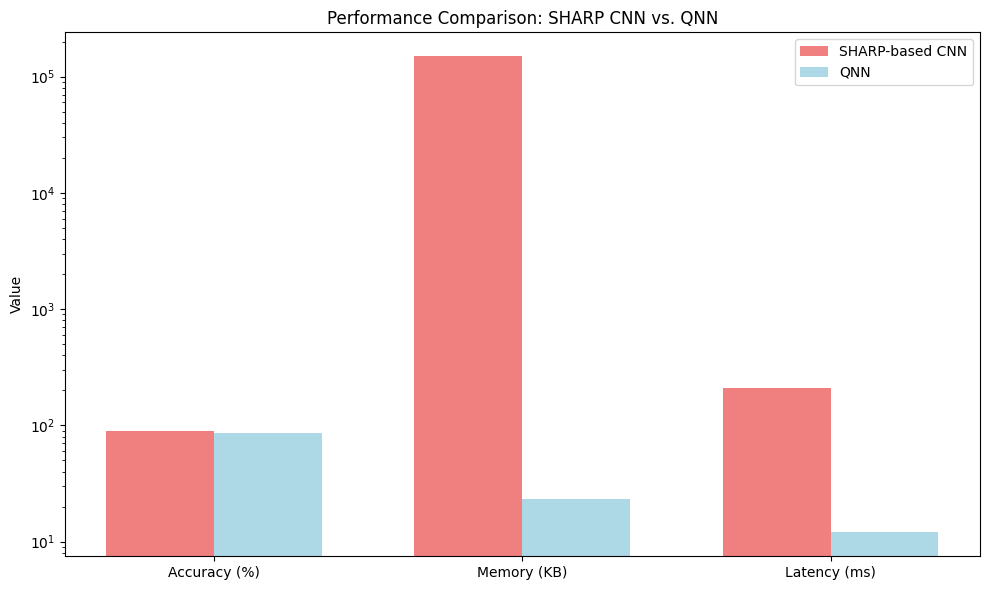

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
labels = ['Accuracy (%)', 'Memory (KB)', 'Latency (ms)']
sharp = [88.7, 150000, 210]
qnn = [86.4, 23.4, 12]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, sharp, width, label='SHARP-based CNN', color='lightcoral')
plt.bar(x + width/2, qnn, width, label='QNN', color='lightblue')

plt.ylabel('Value')
plt.title('Performance Comparison: SHARP CNN vs. QNN')
plt.xticks(x, labels)
plt.yscale('log')  # Log scale to handle big memory difference
plt.legend()
plt.tight_layout()
plt.savefig("fig_sharp_vs_qnn_comparison.png", dpi=300)
plt.show()
